<a href="https://colab.research.google.com/github/Emanuel2234/Causas_muerte_chile_2023_2026/blob/main/Causas_de_Defunci%C3%B3n_chile_2023_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis mineria de datos : Causas de muerte en chile periodo 2023 a 03/2026

Se realiza analsis a casos de muerte en chile en base a un dataset del minsal que cubren el periodo 2023 a marzo del 2026, en el cual veremos las principales causas de muerte en nuestro pais y asi analizar es estilo de vida de los chilenos y chilenas otra cosa que podemos rescatar es la edad a la que muere la poblacion chilena

Enlace de Fuente: https://deis.minsal.cl/#datosabiertos

**Estudiante: Emanuel Farias**

**Curso: MINERIA DE DATOS**

**Seccion: 004D**

**Profesor: Carlos Muñoz**


In [21]:
#se importan las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [22]:
#se importa el dataset
df = pd.read_csv('/content/DEFUNCIONES_FUENTE_DEIS_2023_2026_14042026.csv', encoding='latin-1', sep=';')

In [23]:
# Aseguramos que la Edad sea numérica y renombramos el Sexo
df['EDAD'] = pd.to_numeric(df['EDAD_CANT'], errors='coerce')
df.rename(columns={'SEXO_NOMBRE': 'SEXO'}, inplace=True)

# Fase 1: entendimiento del negocio

In [24]:
df.shape # se logra apreciar 407897 columnas y 28 filas

(407897, 28)

In [25]:
df.columns

Index(['AÑO', 'FECHA_DEF', 'SEXO', 'EDAD_TIPO', 'EDAD_CANT', 'COD_COMUNA',
       'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1',
       'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1',
       'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1',
       'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2',
       'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2',
       'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2',
       'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2',
       'LUGAR_DEFUNCION', 'EDAD'],
      dtype='object')

Aqui se puede ver las columnas que proveiene de este dataset de las cuales podemos decir:

AÑO: año de la defucion (variable númerica).

FECHA_DEF: fecha completa de la misma (variables categoricas).

EDAD_CANT: edad del fallecido (variable númerica).

SEXO: genero del fallecido/a(variables categoricas).

EDAD_TIPO: codigo que indica la unidad de medida (variables categoricas).

NOMBRE_REGION, COMUNA y COD_COMUNA: idicacion de donde ocurrio (variables categoricas).

LUGAR_DEFUNCION: indica si ocurrio en casa, hospital o via publica (variables categoricas).

DIAG1: corresponde al codigo alfanumerico de la enfermedad o condicion (variables categoricas).

GLOSA_CAPITULO_DIAG1:este seria el apartado donde dice que enfermedad es segun el codigo (variables categoricas).

CAPITULO_DIAG1: numero de los capitulos medicos (variables categoricas).

CODIGO_CATEGORIA_DIAG1: codigo jerarquico del diagnostico (variables categoricas).

DIAG2 y sus derivados: trata de los mismo que el diag1 pero solo que es en base a causas externas del fallecimiento, para todas sus dereivadas y la misma es (variables categoricas)

EDAD: variable limpia de la edad cronologica en años (variable númerica).

Causa_Principal: variable target, es la clasificacion agrupada de la causa de muerte (variables categoricas).



In [26]:
df.head()

,AÑO,FECHA_DEF,SEXO,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,...,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION,EDAD
0,2026,23-03-2026,Hombre,1,64,13129.0,San Joaquín,Metropolitana de Santiago,I10X,I00-I99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,64
1,2026,07-03-2026,Hombre,1,71,14107.0,Paillaco,De Los Ríos,C61X,C00-D48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,71
2,2026,09-03-2026,Mujer,1,72,8112.0,Hualpén,Del Bíobío,J841,J00-J99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,72
3,2026,18-01-2026,Hombre,1,70,5801.0,Quilpué,De Valparaíso,C719,C00-D48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,70
4,2026,08-03-2026,Mujer,1,75,13114.0,Las Condes,Metropolitana de Santiago,C56X,C00-D48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,75


le hechamos un pequeño vistazo al contenido del dataset para familiarizarnos con los datos

In [27]:
df.isna().sum()

,0
AÑO,0
FECHA_DEF,0
SEXO,0
EDAD_TIPO,0
EDAD_CANT,0
COD_COMUNA,63
COMUNA,63
NOMBRE_REGION,63
DIAG1,0
CAPITULO_DIAG1,4


# Se logra percibir que todas estas variables poseen nulos

COD_COMUNA

COMUNA

NOMBRE_REGION

GLOSA_CAPITULO_DIAG1

CODIGO_GRUPO_DIAG1

GLOSA_CATEGORIA_DIAG1

CODIGO_SUBCATEGORIA_DIAG1

GLOSA_SUBCATEGORIA_DIAG1

DIAG2

CAPITULO_DIAG2

GLOSA_CAPITULO_DIAG2

CODIGO_GRUPO_DIAG2

GLOSA_GRUPO_DIAG2

CODIGO_CATEGORIA_DIAG2

GLOSA_CATEGORIA_DIAG2

CODIGO_SUBCATEGORIA_DIAG2

GLOSA_SUBCATEGORIA_DIAG2



una de las posibles causas de que haya tantos nulos en los DIAG2 es que puede haber muerto de causas naturales por lo que esa seccion no era necesario llenarla.

la los de comuna y nombre_region podria deberse a las personas en situacion de calle, tambien si fueron extrajeros o transeuntes que su residencia no esta en chile tal cual.



In [28]:
df.describe().round() # se le aplica estadistica a columnas numericas

,AÑO,EDAD_TIPO,EDAD_CANT,COD_COMUNA,EDAD
count,407897.0,407897.0,407897.0,407834.0,407897.0
mean,2024.0,1.0,73.0,9715.0,73.0
std,1.0,0.0,18.0,4018.0,18.0
min,2023.0,0.0,0.0,1101.0,0.0
25%,2023.0,1.0,65.0,6112.0,65.0
50%,2024.0,1.0,77.0,10101.0,77.0
75%,2025.0,1.0,86.0,13121.0,86.0
max,2026.0,9.0,140.0,99999.0,140.0


al comienzo se logra ver la cantidad de registros que seria 407897, luego se muestra la media el año 2024, con tipo de edad 1, 73 años de fallecido (seria el promedio), su respectivo codigo de comuna y otra vez su edad.

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407897 entries, 0 to 407896
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   AÑO                        407897 non-null  int64  
 1   FECHA_DEF                  407897 non-null  object 
 2   SEXO                       407897 non-null  object 
 3   EDAD_TIPO                  407897 non-null  int64  
 4   EDAD_CANT                  407897 non-null  int64  
 5   COD_COMUNA                 407834 non-null  float64
 6   COMUNA                     407834 non-null  object 
 7   NOMBRE_REGION              407834 non-null  object 
 8   DIAG1                      407897 non-null  object 
 9   CAPITULO_DIAG1             407893 non-null  object 
 10  GLOSA_CAPITULO_DIAG1       407893 non-null  object 
 11  CODIGO_GRUPO_DIAG1         407893 non-null  object 
 12  GLOSA_GRUPO_DIAG1          407893 non-null  object 
 13  CODIGO_CATEGORIA_DIAG1     40

In [30]:
# Ver si hay nulos
df.isnull().any().any()

np.True_

si se encontraron nulos por lo que debemos tratarlos

In [31]:
# Conteo de nulos por columna
for col in df.columns:
    print(col, df[col].isna().sum())

AÑO 0
FECHA_DEF 0
SEXO 0
EDAD_TIPO 0
EDAD_CANT 0
COD_COMUNA 63
COMUNA 63
NOMBRE_REGION 63
DIAG1 0
CAPITULO_DIAG1 4
GLOSA_CAPITULO_DIAG1 4
CODIGO_GRUPO_DIAG1 4
GLOSA_GRUPO_DIAG1 4
CODIGO_CATEGORIA_DIAG1 4
GLOSA_CATEGORIA_DIAG1 4
CODIGO_SUBCATEGORIA_DIAG1 4
GLOSA_SUBCATEGORIA_DIAG1 4
DIAG2 284001
CAPITULO_DIAG2 381588
GLOSA_CAPITULO_DIAG2 381588
CODIGO_GRUPO_DIAG2 381588
GLOSA_GRUPO_DIAG2 381588
CODIGO_CATEGORIA_DIAG2 381588
GLOSA_CATEGORIA_DIAG2 381588
CODIGO_SUBCATEGORIA_DIAG2 381588
GLOSA_SUBCATEGORIA_DIAG2 381588
LUGAR_DEFUNCION 0
EDAD 0


se realiza el conteo de nulos

In [32]:
#LIMPIEZA Y TRATAMIENTO DE NULOS

# Separar variables categóricas y numéricas
ctext = df.select_dtypes(include=['object']).columns
cnum = df.select_dtypes(exclude=['object']).columns

# Completando valores faltantes datos cuantitativos con la media
for columna in cnum:
    mean = df[columna].mean()

    df[columna] = df[columna].fillna(mean)

# Completando valores faltantes datos categóricos con la moda
for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)


In [33]:
# Ver si hay nulos
df.isnull().any().any()

np.False_

En este punto los nulos fueron imputados

In [34]:
# CREACIÓN DE VARIABLE OBJETIVO (Clasificación CIE-10 Completa)
def clasificar_todas_las_causas(fila):
    # 1. Primero aislamos las Causas Externas usando DIAG2 (Regla DEIS)
    diag2 = str(fila['DIAG2']).strip().upper()
    if diag2.startswith(('V', 'W', 'X', 'Y')):
        return 'Causas Externas (Accidentes/Violencia)'

    # 2. Agrupamos TODAS las enfermedades principales usando DIAG1
    diag1 = str(fila['DIAG1']).strip().upper()

    if diag1.startswith(('A', 'B')):
        return 'Infecciosas y Parasitarias (ej. COVID, VIH)'
    elif diag1.startswith(('C', 'D')):
        return 'Neoplasias (Cáncer y Tumores)'
    elif diag1.startswith('E'):
        return 'Endocrinas y Nutricionales (ej. Diabetes)'
    elif diag1.startswith('F'):
        return 'Trastornos Mentales y del Comportamiento'
    elif diag1.startswith('G'):
        return 'Enfermedades del Sistema Nervioso'
    elif diag1.startswith('H'):
        return 'Enfermedades del Ojo y Oído'
    elif diag1.startswith('I'):
        return 'Enfermedades del Sistema Circulatorio'
    elif diag1.startswith('J'):
        return 'Enfermedades del Sistema Respiratorio'
    elif diag1.startswith('K'):
        return 'Enfermedades del Sistema Digestivo'
    elif diag1.startswith('L'):
        return 'Enfermedades de la Piel'
    elif diag1.startswith('M'):
        return 'Enfermedades del Sistema Osteomuscular'
    elif diag1.startswith('N'):
        return 'Enfermedades del Sistema Genitourinario'
    elif diag1.startswith('O'):
        return 'Embarazo, Parto y Puerperio'
    elif diag1.startswith('P'):
        return 'Afecciones Perinatales'
    elif diag1.startswith('Q'):
        return 'Malformaciones Congénitas'
    elif diag1.startswith('R'):
        return 'Causas Mal Definidas / Síntomas'
    else:
        return 'Otras Causas / No Especificado'

# Aplicamos la nueva función
df['Causa_Principal'] = df.apply(clasificar_todas_las_causas, axis=1)

print("Distribución Detallada de las Clases (Variable Objetivo):\n")
print(df['Causa_Principal'].value_counts(normalize=True) * 100)

Distribución Detallada de las Clases (Variable Objetivo):

Causa_Principal
Neoplasias (Cáncer y Tumores)                  25.616516
Enfermedades del Sistema Circulatorio          25.094816
Enfermedades del Sistema Respiratorio          11.932424
Enfermedades del Sistema Digestivo              7.188579
Causas Externas (Accidentes/Violencia)          6.449422
Enfermedades del Sistema Nervioso               5.158900
Endocrinas y Nutricionales (ej. Diabetes)       4.174338
Causas Mal Definidas / Síntomas                 3.027970
Enfermedades del Sistema Genitourinario         2.851700
Trastornos Mentales y del Comportamiento        2.807572
Infecciosas y Parasitarias (ej. COVID, VIH)     2.236349
Otras Causas / No Especificado                  1.020846
Enfermedades de la Piel                         0.863208
Enfermedades del Sistema Osteomuscular          0.644035
Malformaciones Congénitas                       0.490810
Afecciones Perinatales                          0.400591
Embarazo, Par

en esta seccion quise clasificar las enfermedades por sus codigo para tener mas claro de que muere la gente en chile en este perido de tiempo, lo quye se logra apreciar que las 5 causas de muerte principales son:

Neoplasias (Cáncer y Tumores) con 25%.

Enfermedades del Sistema Circulatorio          25%.

Enfermedades del Sistema Respiratorio          11%.

Enfermedades del Sistema Digestivo              7%.

Causas Externas (Accidentes/Violencia)          6%.

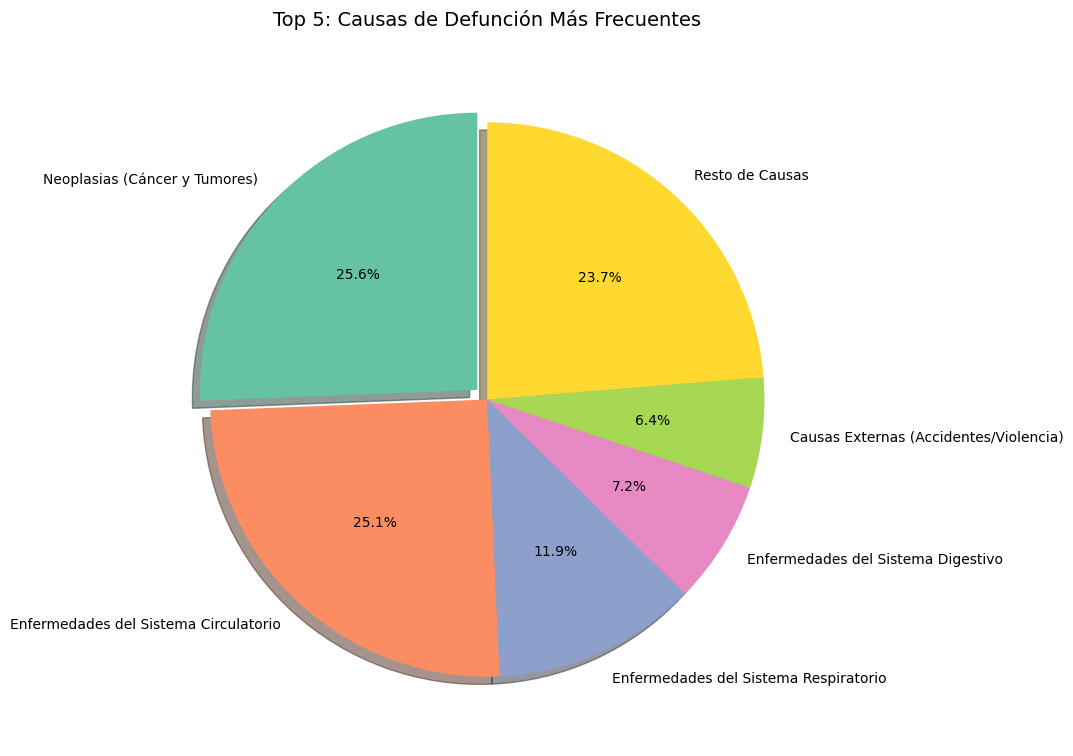

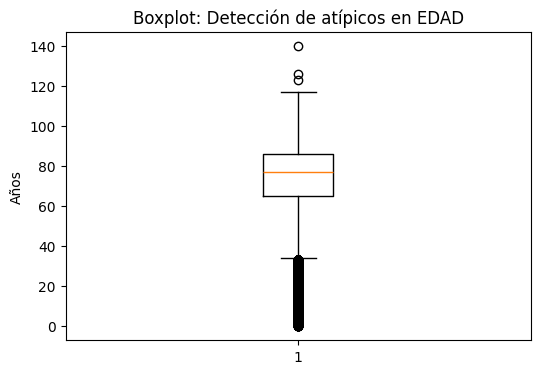

In [35]:
# EXPLORACIÓN VISUAL

# Gráfico de Torta de la Variable Objetivo
plt.figure(figsize=(9, 9))

# Obtenemos todas las frecuencias
frecuencias_completas = df['Causa_Principal'].value_counts()

# se separa el top 5 de el resto de enfermedades
top_5 = frecuencias_completas.nlargest(5)
resto_sumado = pd.Series([frecuencias_completas.iloc[5:].sum()], index=['Resto de Causas'])

# Unimos el Top 5 con la nueva categoría "Resto de Causas"
frecuencias_final = pd.concat([top_5, resto_sumado])
# ---------------------------------------------------------

# Destacamos levemente la causa principal (la posición 0)
explode = [0.05 if i == 0 else 0 for i in range(len(frecuencias_final))]

# Generamos la paleta de colores (necesitamos 6 colores: 5 del top + 1 del resto)
colores = sns.color_palette('Set2', len(frecuencias_final))

# Generamos el gráfico de torta
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Top 5: Causas de Defunción Más Frecuentes', fontsize=14, pad=20)
plt.show()

# B. Boxplot para detectar atípicos en la edad
plt.figure(figsize=(6, 4))
# Usamos dropna() por si quedó algún nulo residual para que no falle el gráfico
plt.boxplot(list(df['EDAD'].dropna()))
plt.title('Boxplot: Detección de atípicos en EDAD')
plt.ylabel('Años')
plt.show()

En el grafico de torta se aprecia las causas de muertes mas frecuentes de las cuales sabemos que:

1.- 25.6% de neoplasias.

2.- 25.1% Enfermedades del sistema circulatorio.

3.- 11.9% Enfermedades del sistema respiratorio.

4.- 7.2% Enfermedades del sistema Digestivo.

5.- 6.4% Accidentes de causas externas (Violencia/accidentes)

y el resto 23.7% de otras causas.


En el boxplot se puede apreciar que los valores dentro de la caja corresponden a la mediana que sabemos que son 77 años, en el borde inferior se encontrarian los 65 años que corresponde al percentil 25, en el borde superior corresponderia a los 86 años, esto nos demuestra que la gente en chile fallece en este rango de edad.

Con respecto la cola inferior de este boxplot se logra apreciar valores atipicos, pero estos podrian representar la mortalidad prematura.

Con respecto a los puntos superiores, puede significar personas que fallecieron con una edad altisima o puede ser que un error en los datos por lo que se vera mas adelante

Filas antes de la limpieza: 407897
Filas después de la limpieza: 407892


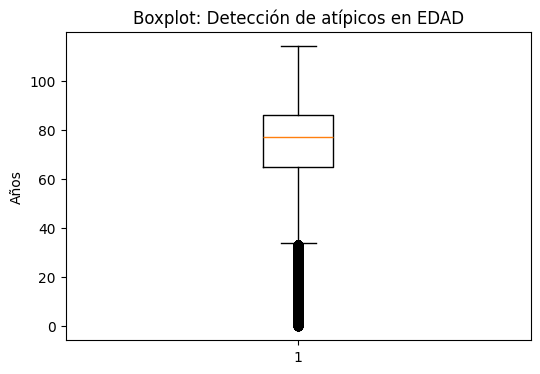

In [36]:
# limpieza de outliers por longevidad
print(f"Filas antes de la limpieza: {len(df)}")

# Filtramos: Nos quedamos solo con las personas que tienen 115 años o menos.
# (Mantenemos intactos a los bebés y jóvenes de 0 a 40 años)
df = df[df['EDAD'] <= 115]

print(f"Filas después de la limpieza: {len(df)}")

# Boxplot para detectar atípicos en la edad
plt.figure(figsize=(6, 4))
# Usamos dropna() por si quedó algún nulo residual para que no falle el gráfico
plt.boxplot(list(df['EDAD'].dropna()))
plt.title('Boxplot: Detección de atípicos en EDAD')
plt.ylabel('Años')
plt.show()

se logro ver que solo 5 personas en todo este periodo de tiempo podrian haber muerto en base a su edad

In [37]:
# Verificación de tipos de datos
print(df[['EDAD', 'SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal']].info())

<class 'pandas.core.frame.DataFrame'>
Index: 407892 entries, 0 to 407896
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   EDAD             407892 non-null  int64 
 1   SEXO             407892 non-null  object
 2   LUGAR_DEFUNCION  407892 non-null  object
 3   Causa_Principal  407892 non-null  object
dtypes: int64(1), object(3)
memory usage: 15.6+ MB
None


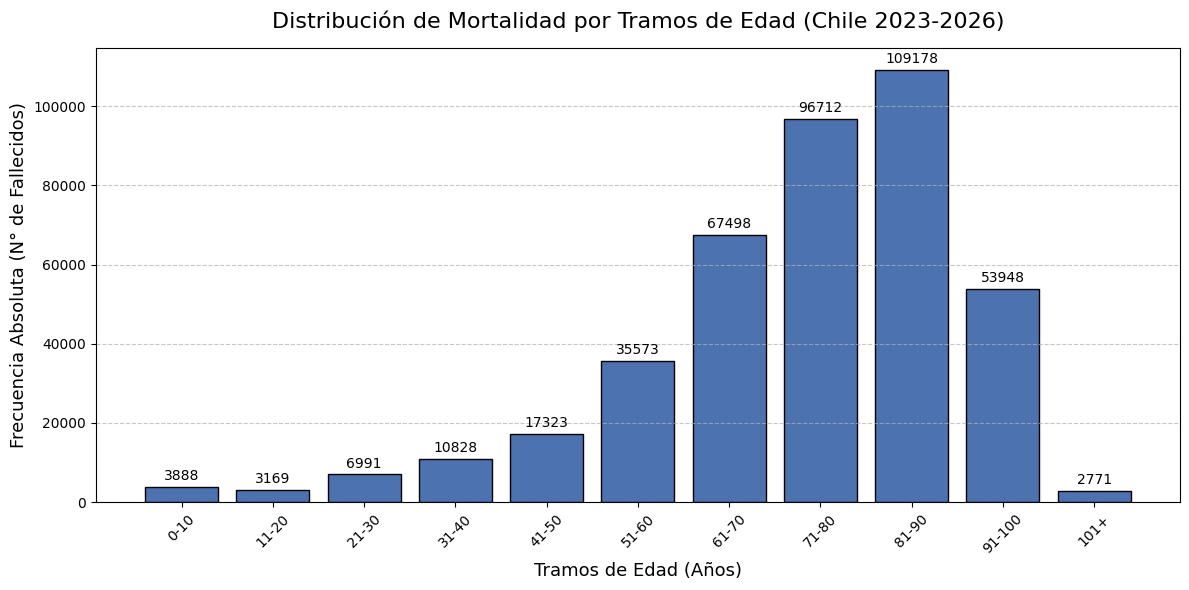

In [40]:
# Definimos los límites de los tramos (bins) y sus etiquetas
# Vamos de 0 a 120 años, saltando de 10 en 10
bins_edad = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120]
etiquetas_edad = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '101+']

# Creamos una nueva columna con el tramo correspondiente para cada persona
df['Tramo_Edad'] = pd.cut(df['EDAD'], bins=bins_edad, labels=etiquetas_edad, right=True)

# Calculamos la frecuencia de muertes por tramo y ordenamos por el índice (de menor a mayor edad)
frecuencia_tramos = df['Tramo_Edad'].value_counts().sort_index()

# Generamos el Gráfico de Barras
plt.figure(figsize=(12, 6))
# Usamos un color profesional y bordes negros para que las barras destaquen
barras = plt.bar(frecuencia_tramos.index, frecuencia_tramos.values, color='#4C72B0', edgecolor='black')

# Agregamos los números arriba de cada barra para mayor precisión
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1000, int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Distribución de Mortalidad por Tramos de Edad (Chile 2023-2026)', fontsize=16, pad=15)
plt.xlabel('Tramos de Edad (Años)', fontsize=13)
plt.ylabel('Frecuencia Absoluta (N° de Fallecidos)', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustamos el layout para que no se corten los textos
plt.tight_layout()
plt.show()

Que podemos rescatar de este grafico?, la mayoria de la poblacion adulta mayor suele morir en este tramo de 81 a 90 años acumulando 109.178 fallecidos seguido del tramo 71 a 80 que serian 96.712 casos

Podemos obserbar en el tramo a partir de los 50 años la mortalidad se dispara, se ven que entre los 41 a 50 y los 51 a 60 se duplica e incluso inprementa un poco mas de la mitad, la cual va incrementando hasta los 80.

Tambien se obserba que las muertes de jovenes son marginales a comparacion de volumen total, destacando el punto con menor mortalidad el tramo entre los 11 a 20 años con 3.169 casos.



Ejecutando modelo con variables de alto impacto...


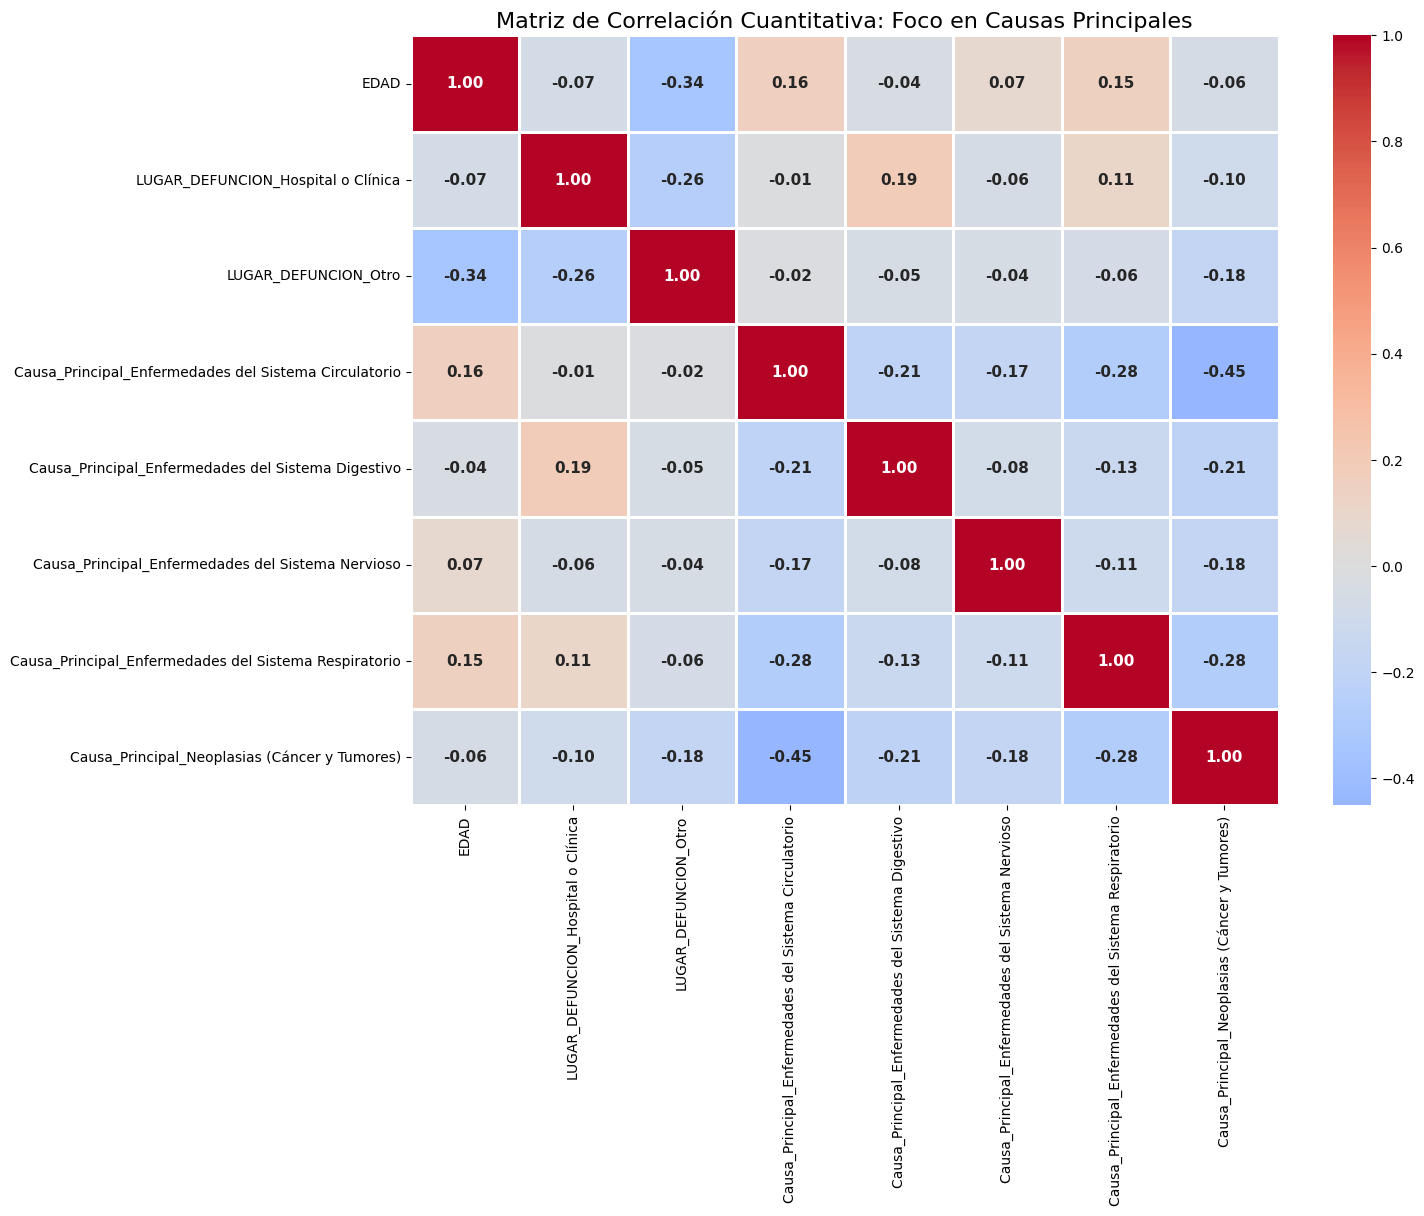

In [39]:
# Identificamos las 6 causas con mayor representatividad
top_causas = df['Causa_Principal'].value_counts().nlargest(6).index.tolist()
print("Ejecutando modelo con variables de alto impacto...")

# Filtramos el DataFrame original
df_final = df[df['Causa_Principal'].isin(top_causas)].copy()

# Selección de Columnas Críticas (Poda de Multicolinealidad y Ruido)
# Mantenemos solo los 'Pesos Pesados': Edad y Lugar
columnas_modelo = ['EDAD', 'LUGAR_DEFUNCION', 'Causa_Principal']

# Transformación: One-Hot Encoding
# drop_first=True evita la trampa de las variables dummy
df_encoded = pd.get_dummies(df_final[columnas_modelo], drop_first=True, dtype=int)

# Generamos la Matriz de Pearson
corr_final = df_encoded.corr()

# Visualizacióncon Anotaciones
plt.figure(figsize=(14, 10))

sns.heatmap(corr_final,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.8,
            annot_kws={"size": 11, "weight": "bold"})

plt.title("Matriz de Correlación Cuantitativa: Foco en Causas Principales", fontsize=16)
plt.xticks(rotation=90)
plt.show()

# 7. Reporte de Influencia para la Variable Objetivo
target = [col for col in corr_final.columns if 'Causas Externas' in col]
if target:
    print(f"\n Factores Determinantes para: {target[0]}")
    # Mostramos los 3 más altos excluyendo la variable misma
    print(corr_final[target[0]].sort_values(ascending=False).iloc[1:4])

Que podemos notar en esta matriz de correlacion de pearson?, bueno entre las variables de EDAD y LUGAR_DEFUNCION_Otro nos dio -0.34 lo que nos indicaria una tendencia sociodemografica que demuestra que a menor edad existe una probabilidad de fallecer fuera de recintos hospitalarios.

Otra cosa que encontramos esta en la Edad que presenta correlacion positiva con las Enfermedades de Sistema Circulatorio con un 0.16 y del Sistema Respiratorio un 0.15, esto confirma que a medida de que la gente envejece suele tener alguna de estas patologias al fallecer.

Tambien podemos intuir con las variables de LUGAR_DEFUNCION_Hospital o clinica junto con las Enfermedades del sistema digestivo un 0.19, y que estas patologias suelen requerir unan hospitalizacion prolongada o intervenciones médicas previas a su muerte a diferencia de otras causas.

Con respecto a la edad y la neoplasias es de -0.06 esto no indica su mortalidad sino la naturaleza de esta patologia, normalmente afecta a la poblacion de edad media de 40-65 años, estas no iran aumentando segun la edad solo es una probabilidad